In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv("/content/Lab_Exam_binary_classification_dataset.csv")

In [5]:
data.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [6]:
data.info

<bound method DataFrame.info of       Feature1  Feature2 Target
0       1.7250       520    Yes
1       1.8875       428     No
2       1.6000       552    Yes
3       1.4250       500     No
4       1.7750       628     No
...        ...       ...    ...
1015    1.8500       492     No
1016    1.7375       412     No
1017    1.6375       444     No
1018    1.6625       632     No
1019    1.5875       628     No

[1020 rows x 3 columns]>

In [7]:
data.describe

<bound method NDFrame.describe of       Feature1  Feature2 Target
0       1.7250       520    Yes
1       1.8875       428     No
2       1.6000       552    Yes
3       1.4250       500     No
4       1.7750       628     No
...        ...       ...    ...
1015    1.8500       492     No
1016    1.7375       412     No
1017    1.6375       444     No
1018    1.6625       632     No
1019    1.5875       628     No

[1020 rows x 3 columns]>

In [10]:
data.isnull().sum()

,0
Feature1,0
Feature2,0
Target,20


In [11]:
data.duplicated().sum()
data.drop_duplicates(inplace=True)

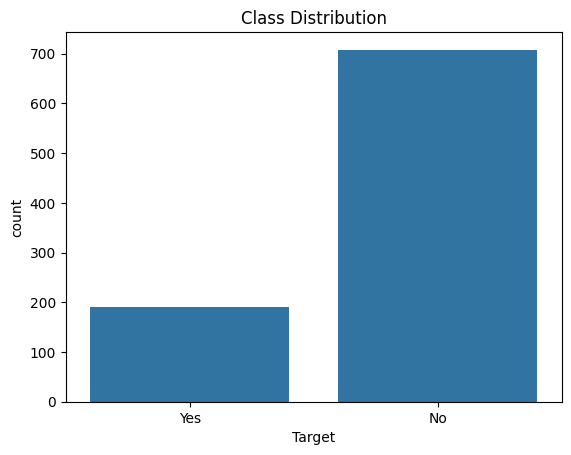

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Target', data=data)
plt.title("Class Distribution")
plt.show()

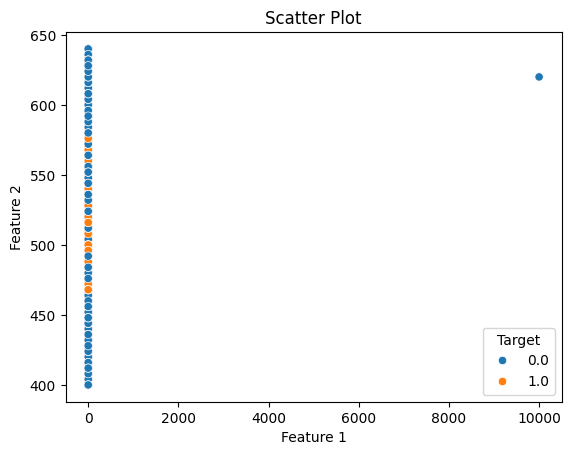

In [22]:
# Encoding
data['Target'] = data['Target'].map({'No': 0, 'Yes': 1})

sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=data)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot')
plt.show()

In [23]:
data['Feature1'].max()

10000.0

In [24]:
data = data[data['Feature1'] < 10]

In [26]:
data.dropna(subset=['Target'], inplace=True)
data['Target'] = data['Target'].astype(int)

In [27]:
from sklearn.preprocessing import StandardScaler

X = data[['Feature1', 'Feature2']]
y = data['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

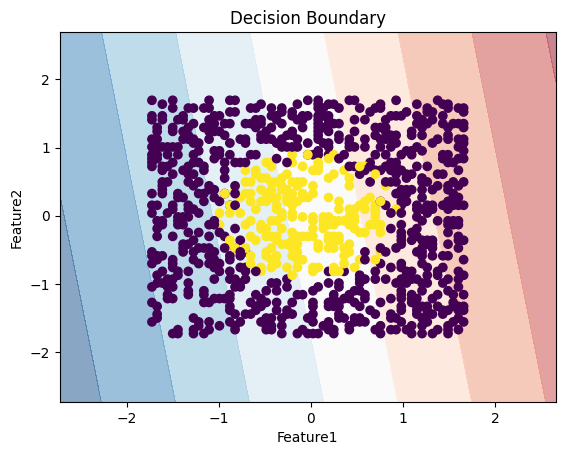

In [29]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

DecisionBoundaryDisplay.from_estimator(
    model,
    X_scaled,
    cmap="RdBu",
    alpha=0.5,
)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.title("Decision Boundary")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7944444444444444


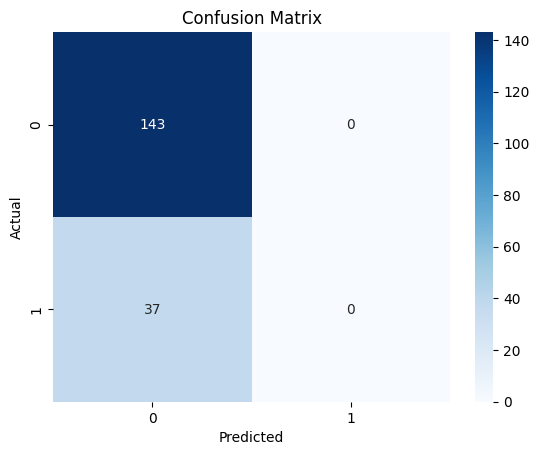

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
from sklearn.tree import DecisionTreeClassifier

# Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

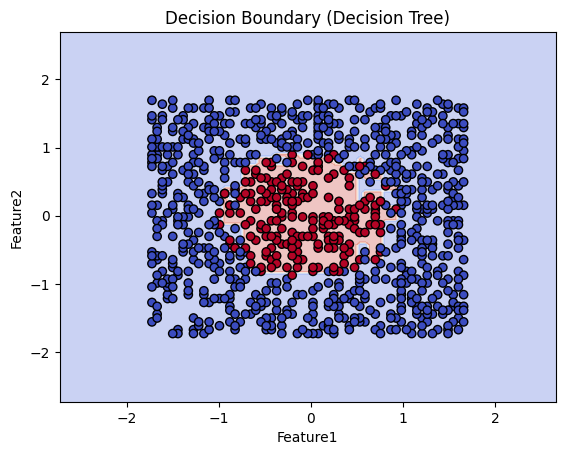

In [33]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

DecisionBoundaryDisplay.from_estimator(
    dt_model,
    X_scaled,
    cmap="coolwarm",
    alpha=0.3,
)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="coolwarm", edgecolors='k')
plt.title("Decision Boundary (Decision Tree)")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9055555555555556

Confusion Matrix:
 [[137   6]
 [ 11  26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94       143
           1       0.81      0.70      0.75        37

    accuracy                           0.91       180
   macro avg       0.87      0.83      0.85       180
weighted avg       0.90      0.91      0.90       180

